# Quark Meson model

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use(["science", "grid"])
import pandas as pd
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import h5py
import plot

In [62]:
RESULTS_DIR = "../results/QM"

In [63]:
csv_path = Path(RESULTS_DIR) / "UV_params.csv"
print(csv_path.resolve())

uv_params = pd.read_csv(
    csv_path, 
    comment='#',
    skiprows=[3],
    skipinitialspace=True
)

uv_params

/home/kilian/Code/FRG/results/QM/UV_params.csv


,-0.1,1,0,0.227838,30.9093,0.1
0,-0.10,1,1.25,0.354673,227.292000,-3.469450e-18
1,-0.10,1,2.50,0.281516,374.808000,4.336810e-19
2,-0.10,1,3.75,0.288094,80.735800,-3.469450e-18
3,-0.10,1,5.00,0.247212,150.836000,-3.469450e-18
4,0.05,1,0.00,0.000000,0.000000,6.709730e-02
5,0.05,1,1.25,0.086096,4.513310,0.000000e+00
6,0.05,1,2.50,0.075726,15.708100,-6.938890e-18
7,0.05,1,3.75,0.079955,2.190710,-8.673620e-19
8,0.05,1,5.00,0.056294,3.369490,1.734720e-18
9,0.20,1,0.00,0.000000,0.000000,2.100930e-01


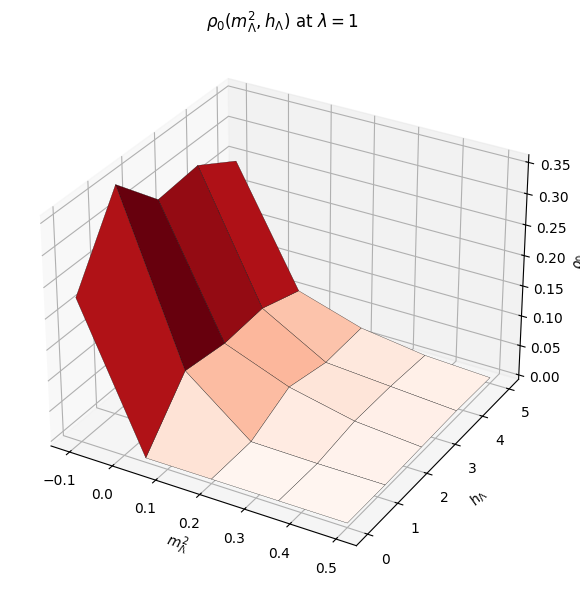

In [70]:
import numpy as np
import matplotlib.pyplot as plt

col_names = ["m2", "lambda", "h", "rho0", "m2_sigma", "m2_pi", "extra"]  # "extra" = phantom col from trailing comma

uv_params = pd.read_csv(
    csv_path,
    comment="#",
    header=None,          
    names=col_names,
    skipinitialspace=True,
)

uv_params = uv_params.drop(columns=["extra"])
uv_params

# Pick a fixed lambda slice (or set this explicitly, e.g. lambda_fixed = 1.0)
lambda_fixed = uv_params["lambda"].iloc[0]
df = uv_params[np.isclose(uv_params["lambda"], lambda_fixed)]

# Pivot into a grid: rows = m2, columns = h
pivot = df.pivot(index="m2", columns="h", values="rho0")

M2, H = np.meshgrid(pivot.index.values, pivot.columns.values, indexing="ij")
RHO0 = pivot.values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(M2, H, RHO0, cmap="Reds", edgecolor="k", linewidth=0.2)

ax.set_xlabel(r"$m^2_\Lambda$")
ax.set_ylabel(r"$h_\Lambda$")
ax.set_zlabel(r"$\rho_0$")
ax.set_title(rf"$\rho_0(m^2_\Lambda, h_\Lambda)$ at $\lambda = {lambda_fixed:.3g}$")

plt.tight_layout()
plt.show()